In [3]:
# Task 1: Data Cleaning and Preprocessing
import pandas as pd 
import numpy as np

df=pd.DataFrame({
    'CustomerID':['C1','C2','C3','C4','C5'],
    'Gender':['Male','Female','Female','Male','Male'],
    'Tenure':[5,24,np.nan,12,3],
    'MonthlyCharges':[70,50,90,60,np.nan],
    'Contract':['Month','Year','Month','Year','Month'],
    'Churn':['Yes','No','No','Yes','Yes']
})
print("Before Cleaning:\n",df,"\n")
# Filling Missing Values
df['Tenure']=df['Tenure'].fillna(df['Tenure'].median())
df['MonthlyCharges']=df['MonthlyCharges'].fillna(df['MonthlyCharges'].mean())

# Encoding Categorial Columns
df['Gender']=df['Gender'].map({'Male':1,'Female':0})
df['Contract']=df['Contract'].map({'Month':0,'Year':1})
df['Churn']=df['Churn'].map({'Yes':1,'No':0})

print("After Cleaning:\n",df)

Before Cleaning:
   CustomerID  Gender  Tenure  MonthlyCharges Contract Churn
0         C1    Male     5.0            70.0    Month   Yes
1         C2  Female    24.0            50.0     Year    No
2         C3  Female     NaN            90.0    Month    No
3         C4    Male    12.0            60.0     Year   Yes
4         C5    Male     3.0             NaN    Month   Yes 

After Cleaning:
   CustomerID  Gender  Tenure  MonthlyCharges  Contract  Churn
0         C1       1     5.0            70.0         0      1
1         C2       0    24.0            50.0         1      0
2         C3       0     8.5            90.0         0      0
3         C4       1    12.0            60.0         1      1
4         C5       1     3.0            67.5         0      1


Overall Churn Rate: 60.0 %


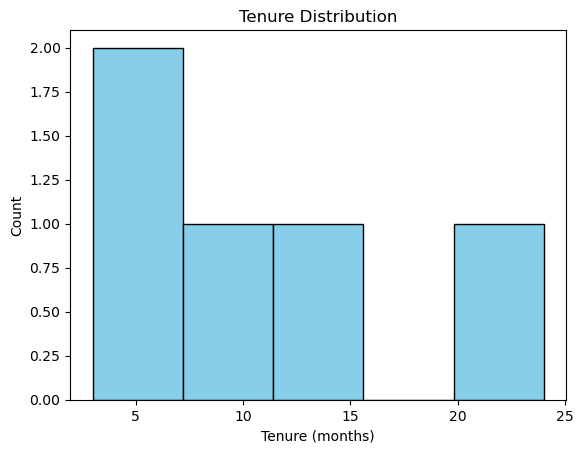

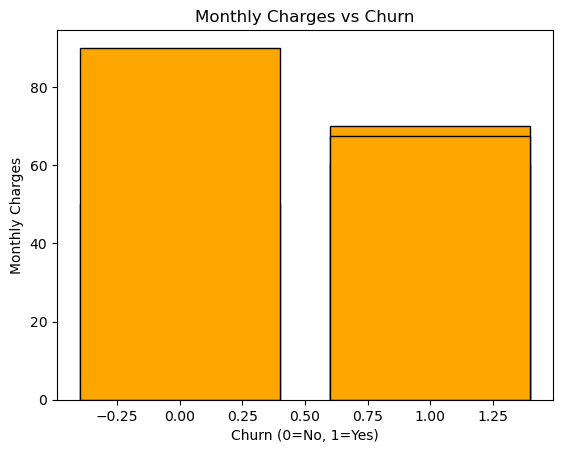

In [7]:
# Task 2: Exploratory Data Analysis
import matplotlib.pyplot as plt
import seaborn as sns

print("Overall Churn Rate:", round(df['Churn'].mean()*100,2), "%")

# Tenure distribution
plt.hist(df['Tenure'], bins=5, color='skyblue', edgecolor='black')
plt.title("Tenure Distribution")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.show()

# Monthly charges vs churn
plt.bar(df['Churn'], df['MonthlyCharges'], color='orange', edgecolor='black')
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn (0=No, 1=Yes)")
plt.ylabel("Monthly Charges")
plt.show()

In [8]:
# Task 3: Customer Segmentation 

# Create Tenure Segments
df['TenureGroup']=pd.cut(df['Tenure'],bins=[0,10,20,30],labels=['Low','Mid','High'])
print("Tenure Segments:\n",df[['CustomerID','Tenure','TenureGroup']],"\n")

# Churn Rate by Segment
churn_seg=df.groupby('TenureGroup')['Churn'].mean().round(2)
print("Churn Rate by Tenure Group:\n",churn_seg)

Tenure Segments:
   CustomerID  Tenure TenureGroup
0         C1     5.0         Low
1         C2    24.0        High
2         C3     8.5         Low
3         C4    12.0         Mid
4         C5     3.0         Low 

Churn Rate by Tenure Group:
 TenureGroup
Low     0.67
Mid     1.00
High    0.00
Name: Churn, dtype: float64


/var/folders/hn/gbfhs2351fjdcdghztbg6d3w0000gn/T/ipykernel_1137/828240927.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_seg=df.groupby('TenureGroup')['Churn'].mean().round(2)


In [9]:
# Task 4: Churn Prediction Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Features and Target
x=df[['Gender','Tenure','MonthlyCharges','Contract']]
y=df['Churn']

# Split Data
x_train,x_test,y_train ,y_test=train_test_split(x,y,test_size=0.4,random_state=42)

# Train Logistic Regression Model
model=LogisticRegression()
model.fit(x_train,y_train)

# Predict and Evaluate
y_pred=model.predict(x_test)
acc=accuracy_score(y_test,y_pred)

print("Predicted Labels: ",y_pred)
print("Model Accuracy: ",round(acc*100,2),"%")

Predicted Labels:  [1 1]
Model Accuracy:  50.0 %


In [11]:
# Task 5: Customer Retention Strategies

# Compute simple customer Lifetime Value (LTV)
df['LTV']=df['Tenure']*df['MonthlyCharges']
print("Customer Lifetime Value (LTV):\n",df[['CustomerID','LTV','Churn']],"\n")

print("Suggested Retention Strategies: ")
print("1]Offer loyalty rewards to long-term customers.")
print("2]Create flexible plans for new users to reduce early churn.")
print("3]Provide personalized offers to high LTV Customers.")

Customer Lifetime Value (LTV):
   CustomerID     LTV  Churn
0         C1   350.0      1
1         C2  1200.0      0
2         C3   765.0      0
3         C4   720.0      1
4         C5   202.5      1 

Suggested Retention Strategies: 
1]Offer loyalty rewards to long-term customers.
2]Create flexible plans for new users to reduce early churn.
3]Provide personalized offers to high LTV Customers.


In [2]:
# Task 6: Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: for corr()
import numpy as np
import pandas as pd

